## NEW EXPERIMENTS

The architecture of your network will contain:


Note:- Please go below for new experiments above codes are pix2pix model

## Import TensorFlow and other libraries

In [2]:
import tensorflow as tf

import os
import pathlib
import time
import datetime

from matplotlib import pyplot as plt
from IPython import display

gpus = tf.config.list_physical_devices('GPU')

tf.config.set_visible_devices(gpus[2], 'GPU')
tf.config.experimental.set_memory_growth(gpus[2], True)

## Load the dataset

Download the CMP Facade Database data (30MB). Additional datasets are available in the same format [here](http://efrosgans.eecs.berkeley.edu/pix2pix/datasets/). In Colab you can select other datasets from the drop-down menu. Note that some of the other datasets are significantly larger (`edges2handbags` is 8GB in size). 

In [3]:
dataset_name = "facades"

In [4]:
# _URL = f'http://efrosgans.eecs.berkeley.edu/pix2pix/datasets/{dataset_name}.tar.gz'

# path_to_zip = tf.keras.utils.get_file(
#     fname=f"{dataset_name}.tar.gz",
#     origin=_URL,
#     extract=True)

# path_to_zip  = pathlib.Path(path_to_zip)

PATH = '../datasets/facades'

Each original image is of size `256 x 512` containing two `256 x 256` images:

In [4]:
sample_image = tf.io.read_file(str(PATH + '/train/1.jpg'))
sample_image = tf.io.decode_jpeg(sample_image)
print(sample_image.shape)

(256, 512, 3)


I0000 00:00:1747567058.257253 2999076 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 44411 MB memory:  -> device: 2, name: NVIDIA RTX A6000, pci bus id: 0000:81:00.0, compute capability: 8.6


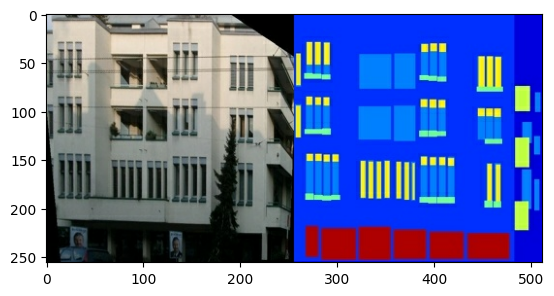

In [5]:
plt.figure()
plt.imshow(sample_image)

You need to separate real building facade images from the architecture label images—all of which will be of size `256 x 256`.

Define a function that loads image files and outputs two image tensors:

In [5]:
def load(image_file):
  # Read and decode an image file to a uint8 tensor
  image = tf.io.read_file(image_file)
  image = tf.io.decode_jpeg(image)

  w = tf.shape(image)[1]
  w = w // 2
  input_image = image[:, w:, :]
  real_image = image[:, :w, :]

  # Convert both images to float32 tensors
  input_image = tf.cast(input_image, tf.float32)
  real_image = tf.cast(real_image, tf.float32)

  return input_image, real_image

Plot a sample of the input (architecture label image) and real (building facade photo) images:

I0000 00:00:1747579359.465594 3123739 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 44150 MB memory:  -> device: 2, name: NVIDIA RTX A6000, pci bus id: 0000:81:00.0, compute capability: 8.6


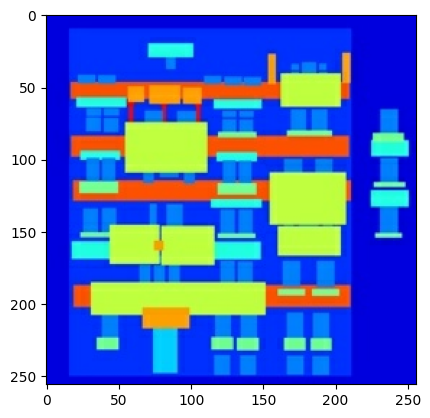

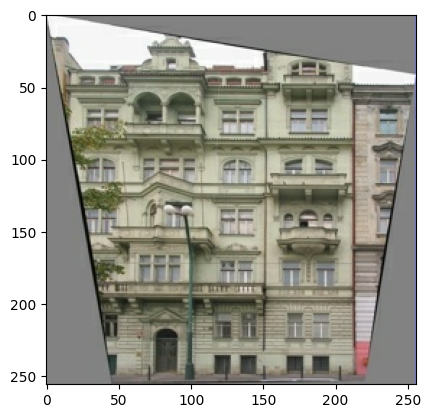

In [6]:
inp, re = load(str(PATH + '/train/100.jpg'))
# Casting to int for matplotlib to display the images
plt.figure()
plt.imshow(inp / 255.0)
plt.figure()
plt.imshow(re / 255.0)

As described in the [pix2pix paper](https://arxiv.org/abs/1611.07004), you need to apply random jittering and mirroring to preprocess the training set.

Define several functions that:

1. Resize each `256 x 256` image to a larger height and width—`286 x 286`.
2. Randomly crop it back to `256 x 256`.
3. Randomly flip the image horizontally i.e., left to right (random mirroring).
4. Normalize the images to the `[-1, 1]` range.

In [7]:
# The facade training set consist of 400 images
BUFFER_SIZE = 400
# The batch size of 1 produced better results for the U-Net in the original pix2pix experiment
BATCH_SIZE = 1
# Each image is 256x256 in size
IMG_WIDTH = 256
IMG_HEIGHT = 256

In [8]:
def resize(input_image, real_image, height, width):
  input_image = tf.image.resize(input_image, [height, width],
                                method=tf.image.ResizeMethod.NEAREST_NEIGHBOR)
  real_image = tf.image.resize(real_image, [height, width],
                               method=tf.image.ResizeMethod.NEAREST_NEIGHBOR)

  return input_image, real_image

In [9]:
def random_crop(input_image, real_image):
  stacked_image = tf.stack([input_image, real_image], axis=0)
  cropped_image = tf.image.random_crop(
      stacked_image, size=[2, IMG_HEIGHT, IMG_WIDTH, 3])

  return cropped_image[0], cropped_image[1]

In [71]:
# Normalizing the images to [-1, 1]
def normalize(input_image, real_image):
  input_image = (input_image / 127.5) - 1
  real_image = (real_image / 127.5) - 1

  return input_image, real_image

In [11]:
@tf.function()
def random_jitter(input_image, real_image):
  # Resizing to 286x286
  input_image, real_image = resize(input_image, real_image, 286, 286)

  # Random cropping back to 256x256
  input_image, real_image = random_crop(input_image, real_image)

  if tf.random.uniform(()) > 0.5:
    # Random mirroring
    input_image = tf.image.flip_left_right(input_image)
    real_image = tf.image.flip_left_right(real_image)

  return input_image, real_image

You can inspect some of the preprocessed output:

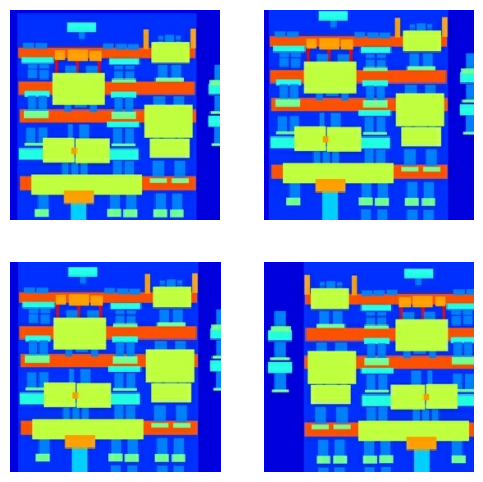

In [12]:
plt.figure(figsize=(6, 6))
for i in range(4):
  rj_inp, rj_re = random_jitter(inp, re)
  plt.subplot(2, 2, i + 1)
  plt.imshow(rj_inp / 255.0)
  plt.axis('off')
plt.show()

Having checked that the loading and preprocessing works, let's define a couple of helper functions that load and preprocess the training and test sets:

In [13]:
def load_image_train(image_file):
  input_image, real_image = load(image_file)
  input_image, real_image = random_jitter(input_image, real_image)
  input_image, real_image = normalize(input_image, real_image)

  return input_image, real_image

In [14]:
def load_image_test(image_file):
  input_image, real_image = load(image_file)
  input_image, real_image = resize(input_image, real_image,
                                   IMG_HEIGHT, IMG_WIDTH)
  input_image, real_image = normalize(input_image, real_image)

  return input_image, real_image

## Build an input pipeline with `tf.data`

In [16]:
train_dataset = tf.data.Dataset.list_files(str(PATH + '/train/*.jpg'))
train_dataset = train_dataset.map(load_image_train,
                                  num_parallel_calls=tf.data.AUTOTUNE)
train_dataset = train_dataset.shuffle(BUFFER_SIZE)
train_dataset = train_dataset.batch(BATCH_SIZE)

In [17]:
try:
  test_dataset = tf.data.Dataset.list_files(str(PATH + '/test/*.jpg'))
except tf.errors.InvalidArgumentError:
  test_dataset = tf.data.Dataset.list_files(str(PATH + '/val/*.jpg'))
test_dataset = test_dataset.map(load_image_test)
test_dataset = test_dataset.batch(BATCH_SIZE)

## Build the generator

The generator of your pix2pix cGAN is a _modified_ [U-Net](https://arxiv.org/abs/1505.04597). A U-Net consists of an encoder (downsampler) and decoder (upsampler). (You can find out more about it in the [Image segmentation](../images/segmentation.ipynb) tutorial and on the [U-Net project website](https://lmb.informatik.uni-freiburg.de/people/ronneber/u-net/).)

- Each block in the encoder is: Convolution -> Batch normalization -> Leaky ReLU
- Each block in the decoder is: Transposed convolution -> Batch normalization -> Dropout (applied to the first 3 blocks) -> ReLU
- There are skip connections between the encoder and decoder (as in the U-Net).

Define the downsampler (encoder):

In [15]:
OUTPUT_CHANNELS = 3

In [16]:
def downsample(filters, size, apply_batchnorm=True):
  initializer = tf.random_normal_initializer(0., 0.02)

  result = tf.keras.Sequential()
  result.add(
      tf.keras.layers.Conv2D(filters, size, strides=2, padding='same',
                             kernel_initializer=initializer, use_bias=False))

  if apply_batchnorm:
    result.add(tf.keras.layers.BatchNormalization())

  result.add(tf.keras.layers.LeakyReLU())

  return result

In [19]:
import tensorflow as tf
print(tf.__version__)
print("cuDNN enabled:", tf.test.is_built_with_cuda())


2.19.0
cuDNN enabled: True


In [17]:
down_model = downsample(3, 4)
down_result = down_model(tf.expand_dims(inp, 0))
print (down_result.shape)

I0000 00:00:1747579387.520075 3123739 cuda_dnn.cc:529] Loaded cuDNN version 90501


(1, 128, 128, 3)


Define the upsampler (decoder):

In [18]:
def upsample(filters, size, apply_dropout=False):
  initializer = tf.random_normal_initializer(0., 0.02)

  result = tf.keras.Sequential()
  result.add(
    tf.keras.layers.Conv2DTranspose(filters, size, strides=2,
                                    padding='same',
                                    kernel_initializer=initializer,
                                    use_bias=False))

  result.add(tf.keras.layers.BatchNormalization())

  if apply_dropout:
      result.add(tf.keras.layers.Dropout(0.5))

  result.add(tf.keras.layers.ReLU())

  return result

In [15]:
up_model = upsample(3, 4)
up_result = up_model(down_result)
print (up_result.shape)

(1, 256, 256, 3)


Define the generator with the downsampler and the upsampler:

In [87]:
def Generator():
  inputs = tf.keras.layers.Input(shape=[256, 256, 3])

  down_stack = [
    downsample(64, 4, apply_batchnorm=False),  # (batch_size, 128, 128, 64)
    downsample(128, 4),  # (batch_size, 64, 64, 128)
    downsample(256, 4),  # (batch_size, 32, 32, 256)
    downsample(512, 4),  # (batch_size, 16, 16, 512)
    downsample(512, 4),  # (batch_size, 8, 8, 512)
    downsample(512, 4),  # (batch_size, 4, 4, 512)
    downsample(512, 4),  # (batch_size, 2, 2, 512)
    downsample(512, 4),  # (batch_size, 1, 1, 512)
  ]

  up_stack = [
    upsample(512, 4, apply_dropout=True),  # (batch_size, 2, 2, 1024)
    upsample(512, 4, apply_dropout=True),  # (batch_size, 4, 4, 1024)
    upsample(512, 4, apply_dropout=True),  # (batch_size, 8, 8, 1024)
    upsample(512, 4),  # (batch_size, 16, 16, 1024)
    upsample(256, 4),  # (batch_size, 32, 32, 512)
    upsample(128, 4),  # (batch_size, 64, 64, 256)
    upsample(64, 4),  # (batch_size, 128, 128, 128)
  ]

  initializer = tf.random_normal_initializer(0., 0.02)
  last = tf.keras.layers.Conv2DTranspose(OUTPUT_CHANNELS, 4,
                                         strides=2,
                                         padding='same',
                                         kernel_initializer=initializer,
                                         activation='tanh')  # (batch_size, 256, 256, 3)

  x = inputs

  # Downsampling through the model
  skips = []
  for down in down_stack:
    x = down(x)
    skips.append(x)

  skips = reversed(skips[:-1])

  # Upsampling and establishing the skip connections
  for up, skip in zip(up_stack, skips):
    x = up(x)
    x = tf.keras.layers.Concatenate()([x, skip])

  x = last(x)

  return tf.keras.Model(inputs=inputs, outputs=x)

Visualize the generator model architecture:

In [25]:
generator = Generator()
tf.keras.utils.plot_model(generator, show_shapes=True, dpi=64)

You must install pydot (`pip install pydot`) for `plot_model` to work.


Test the generator:

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].


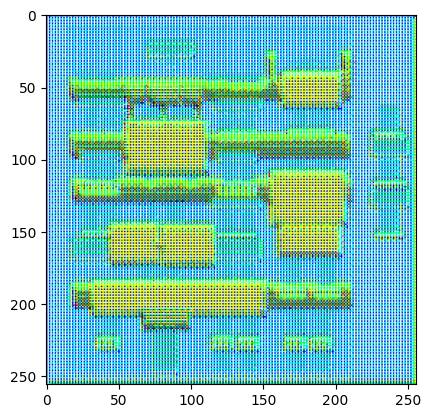

In [26]:
gen_output = generator(inp[tf.newaxis, ...], training=False)
plt.imshow(gen_output[0, ...])

### Define the generator loss

GANs learn a loss that adapts to the data, while cGANs learn a structured loss that penalizes a possible structure that differs from the network output and the target image, as described in the [pix2pix paper](https://arxiv.org/abs/1611.07004).

- The generator loss is a sigmoid cross-entropy loss of the generated images and an **array of ones**.
- The pix2pix paper also mentions the L1 loss, which is a MAE (mean absolute error) between the generated image and the target image.
- This allows the generated image to become structurally similar to the target image.
- The formula to calculate the total generator loss is `gan_loss + LAMBDA * l1_loss`, where `LAMBDA = 100`. This value was decided by the authors of the paper.

In [27]:
LAMBDA = 100

In [28]:
loss_object = tf.keras.losses.BinaryCrossentropy(from_logits=True)

In [29]:
def generator_loss(disc_generated_output, gen_output, target):
  gan_loss = loss_object(tf.ones_like(disc_generated_output), disc_generated_output)

  # Mean absolute error
  l1_loss = tf.reduce_mean(tf.abs(target - gen_output))

  total_gen_loss = gan_loss + (LAMBDA * l1_loss)

  return total_gen_loss, gan_loss, l1_loss

The training procedure for the generator is as follows:

![Generator Update Image](https://github.com/tensorflow/docs/blob/master/site/en/tutorials/generative/images/gen.png?raw=1)


## Build the discriminator

The discriminator in the pix2pix cGAN is a convolutional PatchGAN classifier—it tries to classify if each image _patch_ is real or not real, as described in the [pix2pix paper](https://arxiv.org/abs/1611.07004).

- Each block in the discriminator is: Convolution -> Batch normalization -> Leaky ReLU.
- The shape of the output after the last layer is `(batch_size, 30, 30, 1)`.
- Each `30 x 30` image patch of the output classifies a `70 x 70` portion of the input image.
- The discriminator receives 2 inputs: 
    - The input image and the target image, which it should classify as real.
    - The input image and the generated image (the output of the generator), which it should classify as fake.
    - Use `tf.concat([inp, tar], axis=-1)` to concatenate these 2 inputs together.

Let's define the discriminator:

In [30]:
def Discriminator():
  initializer = tf.random_normal_initializer(0., 0.02)

  inp = tf.keras.layers.Input(shape=[256, 256, 3], name='input_image')
  tar = tf.keras.layers.Input(shape=[256, 256, 3], name='target_image')

  x = tf.keras.layers.concatenate([inp, tar])  # (batch_size, 256, 256, channels*2)

  down1 = downsample(64, 4, False)(x)  # (batch_size, 128, 128, 64)
  down2 = downsample(128, 4)(down1)  # (batch_size, 64, 64, 128)
  down3 = downsample(256, 4)(down2)  # (batch_size, 32, 32, 256)

  zero_pad1 = tf.keras.layers.ZeroPadding2D()(down3)  # (batch_size, 34, 34, 256)
  conv = tf.keras.layers.Conv2D(512, 4, strides=1,
                                kernel_initializer=initializer,
                                use_bias=False)(zero_pad1)  # (batch_size, 31, 31, 512)

  batchnorm1 = tf.keras.layers.BatchNormalization()(conv)

  leaky_relu = tf.keras.layers.LeakyReLU()(batchnorm1)

  zero_pad2 = tf.keras.layers.ZeroPadding2D()(leaky_relu)  # (batch_size, 33, 33, 512)

  last = tf.keras.layers.Conv2D(1, 4, strides=1,
                                kernel_initializer=initializer)(zero_pad2)  # (batch_size, 30, 30, 1)

  return tf.keras.Model(inputs=[inp, tar], outputs=last)

Visualize the discriminator model architecture:

In [31]:
discriminator = Discriminator()
tf.keras.utils.plot_model(discriminator, show_shapes=True, dpi=64)

You must install pydot (`pip install pydot`) for `plot_model` to work.


Test the discriminator:

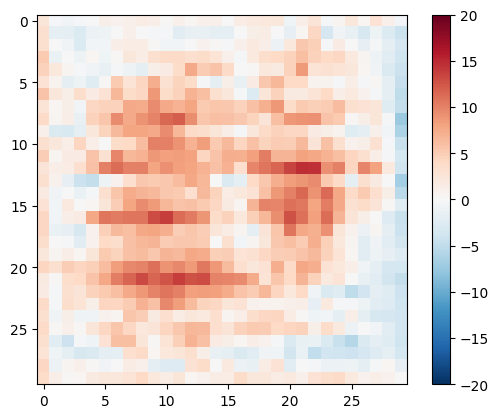

In [32]:
disc_out = discriminator([inp[tf.newaxis, ...], gen_output], training=False)
plt.imshow(disc_out[0, ..., -1], vmin=-20, vmax=20, cmap='RdBu_r')
plt.colorbar()

### Define the discriminator loss

- The `discriminator_loss` function takes 2 inputs: **real images** and **generated images**.
- `real_loss` is a sigmoid cross-entropy loss of the **real images** and an **array of ones(since these are the real images)**.
- `generated_loss` is a sigmoid cross-entropy loss of the **generated images** and an **array of zeros (since these are the fake images)**.
- The `total_loss` is the sum of `real_loss` and `generated_loss`.

In [33]:
def discriminator_loss(disc_real_output, disc_generated_output):
  real_loss = loss_object(tf.ones_like(disc_real_output), disc_real_output)

  generated_loss = loss_object(tf.zeros_like(disc_generated_output), disc_generated_output)

  total_disc_loss = real_loss + generated_loss

  return total_disc_loss

The training procedure for the discriminator is shown below.

To learn more about the architecture and the hyperparameters you can refer to the [pix2pix paper](https://arxiv.org/abs/1611.07004).

![Discriminator Update Image](https://github.com/tensorflow/docs/blob/master/site/en/tutorials/generative/images/dis.png?raw=1)


## Define the optimizers and a checkpoint-saver


In [34]:
generator_optimizer = tf.keras.optimizers.Adam(2e-4, beta_1=0.5)
discriminator_optimizer = tf.keras.optimizers.Adam(2e-4, beta_1=0.5)

In [35]:
current_ts = int(time.time())
checkpoint_dir = './training_checkpoints'
checkpoint_prefix = os.path.join(checkpoint_dir, "ckpt")
checkpoint = tf.train.Checkpoint(generator_optimizer=generator_optimizer,
                                 discriminator_optimizer=discriminator_optimizer,
                                 generator=generator,
                                 discriminator=discriminator)

## Generate images

Write a function to plot some images during training.

- Pass images from the test set to the generator.
- The generator will then translate the input image into the output.
- The last step is to plot the predictions and _voila_!

Note: The `training=True` is intentional here since you want the batch statistics, while running the model on the test dataset. If you use `training=False`, you get the accumulated statistics learned from the training dataset (which you don't want).

In [83]:
def generate_images(model, test_input, tar):
  prediction = model(test_input, training=True)
  plt.figure(figsize=(15, 15))

  display_list = [test_input[0], tar[0], prediction[0]]
  title = ['Input Image', 'Ground Truth', 'Predicted Image']

  for i in range(3):
    plt.subplot(1, 3, i+1)
    plt.title(title[i])
    # Getting the pixel values in the [0, 1] range to plot.
    plt.imshow(display_list[i] * 0.5 + 0.5)
    plt.axis('off')
  plt.show()
  return prediction[0]

In [ ]:
# try:
test_dataset = tf.data.Dataset.list_files('/mnt/e_disk/ch24s016/ee6180_assignment1/pix2pix/datasets/facades/test/*jpg')
# except tf.errors.InvalidArgumentError:
#   test_dataset = tf.data.Dataset.list_files(str(PATH + '/val/*.jpg'))
test_dataset = test_dataset.map(load_image_test)
test_dataset = test_dataset.batch(BATCH_SIZE)

Test the function:

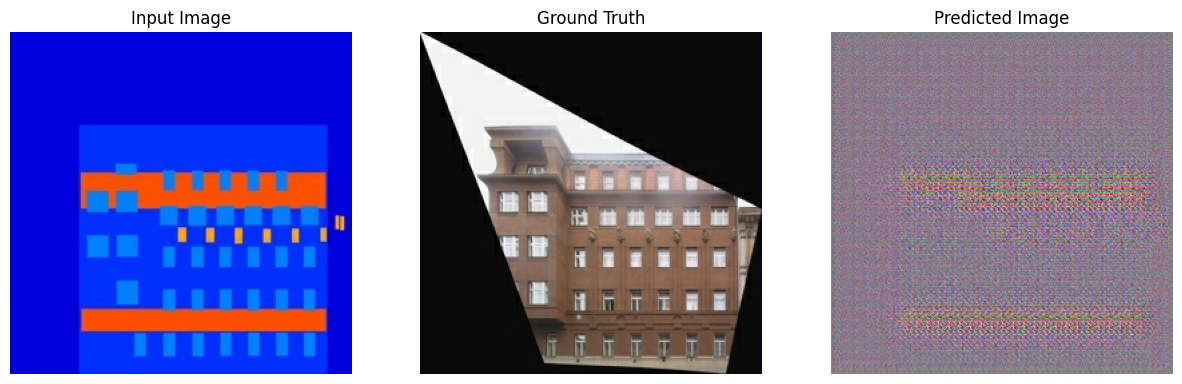

2025-05-18 16:47:45.843194: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [38]:
for example_input, example_target in test_dataset.take(1):
  generate_images(generator, example_input, example_target)

## Training

- For each example input generates an output.
- The discriminator receives the `input_image` and the generated image as the first input. The second input is the `input_image` and the `target_image`.
- Next, calculate the generator and the discriminator loss.
- Then, calculate the gradients of loss with respect to both the generator and the discriminator variables(inputs) and apply those to the optimizer.
- Finally, log the losses to TensorBoard.

In [39]:
log_dir="logs/"

summary_writer = tf.summary.create_file_writer(
  log_dir + "fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S"))

In [40]:
@tf.function
def train_step(input_image, target, step):
  with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
    gen_output = generator(input_image, training=True)

    disc_real_output = discriminator([input_image, target], training=True)
    disc_generated_output = discriminator([input_image, gen_output], training=True)

    gen_total_loss, gen_gan_loss, gen_l1_loss = generator_loss(disc_generated_output, gen_output, target)
    disc_loss = discriminator_loss(disc_real_output, disc_generated_output)

  generator_gradients = gen_tape.gradient(gen_total_loss,
                                          generator.trainable_variables)
  discriminator_gradients = disc_tape.gradient(disc_loss,
                                               discriminator.trainable_variables)

  generator_optimizer.apply_gradients(zip(generator_gradients,
                                          generator.trainable_variables))
  discriminator_optimizer.apply_gradients(zip(discriminator_gradients,
                                              discriminator.trainable_variables))

  with summary_writer.as_default():
    tf.summary.scalar('gen_total_loss', gen_total_loss, step=step//1000)
    tf.summary.scalar('gen_gan_loss', gen_gan_loss, step=step//1000)
    tf.summary.scalar('gen_l1_loss', gen_l1_loss, step=step//1000)
    tf.summary.scalar('disc_loss', disc_loss, step=step//1000)

The actual training loop. Since this tutorial can run of more than one dataset, and the datasets vary greatly in size the training loop is setup to work in steps instead of epochs.

- Iterates over the number of steps.
- Every 10 steps print a dot (`.`).
- Every 1k steps: clear the display and run `generate_images` to show the progress.
- Every 5k steps: save a checkpoint.

In [41]:
def fit(train_ds, test_ds, steps):
  example_input, example_target = next(iter(test_ds.take(1)))
  start = time.time()

  for step, (input_image, target) in train_ds.repeat().take(steps).enumerate():
    if (step) % 1000 == 0:
      display.clear_output(wait=True)

      if step != 0:
        print(f'Time taken for 1000 steps: {time.time()-start:.2f} sec\n')

      start = time.time()

      generate_images(generator, example_input, example_target)
      print(f"Step: {step//1000}k")

    train_step(input_image, target, step)

    # Training step
    if (step+1) % 10 == 0:
      print('.', end='', flush=True)


    # Save (checkpoint) the model every 5k steps
    if (step + 1) % 5000 == 0:
      checkpoint.save(file_prefix=checkpoint_prefix)

This training loop saves logs that you can view in TensorBoard to monitor the training progress.

If you work on a local machine, you would launch a separate TensorBoard process. When working in a notebook, launch the viewer before starting the training to monitor with TensorBoard.

Launch the TensorBoard viewer (Sorry, this doesn't
display on tensorflow.org):

Finally, run the training loop:

Time taken for 1000 steps: 31.42 sec



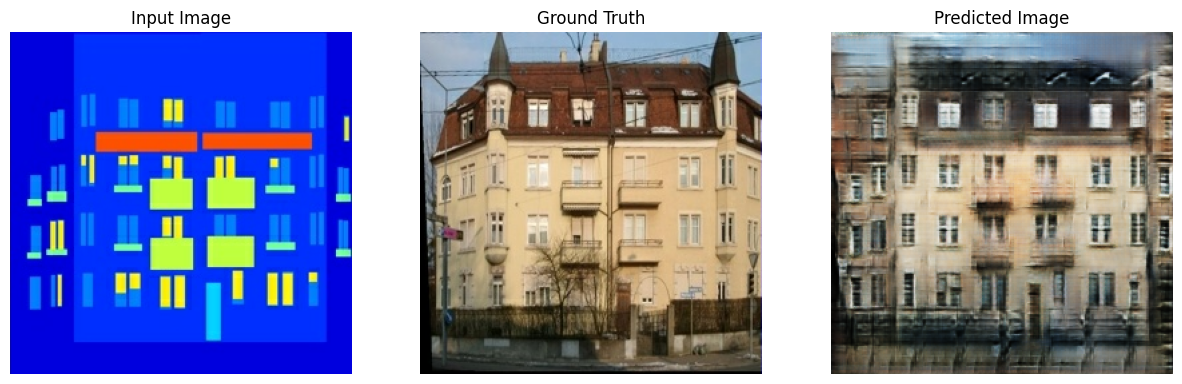

Step: 39k
....................................................................................................

2025-05-18 17:10:53.107587: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [ ]:
# fit(train_dataset, test_dataset, steps=40000)

Interpreting the logs is more subtle when training a GAN (or a cGAN like pix2pix) compared to a simple classification or regression model. Things to look for:

- Check that neither the generator nor the discriminator model has "won". If either the `gen_gan_loss` or the `disc_loss` gets very low, it's an indicator that this model is dominating the other, and you are not successfully training the combined model.
- The value `log(2) = 0.69` is a good reference point for these losses, as it indicates a perplexity of 2 - the discriminator is, on average, equally uncertain about the two options.
- For the `disc_loss`, a value below `0.69` means the discriminator is doing better than random on the combined set of real and generated images.
- For the `gen_gan_loss`, a value below `0.69` means the generator is doing better than random at fooling the discriminator.
- As training progresses, the `gen_l1_loss` should go down.

## Restore the latest checkpoint and test the network

In [43]:
!ls {checkpoint_dir}

checkpoint		    ckpt-5.data-00000-of-00001
ckpt-1.data-00000-of-00001  ckpt-5.index
ckpt-1.index		    ckpt-6.data-00000-of-00001
ckpt-2.data-00000-of-00001  ckpt-6.index
ckpt-2.index		    ckpt-7.data-00000-of-00001
ckpt-3.data-00000-of-00001  ckpt-7.index
ckpt-3.index		    ckpt-8.data-00000-of-00001
ckpt-4.data-00000-of-00001  ckpt-8.index
ckpt-4.index


In [ ]:
# Restoring the latest checkpoint in checkpoint_dir
# checkpoint.restore(tf.train.latest_checkpoint(checkpoint_dir))

## Images Generated on Facades Datasset

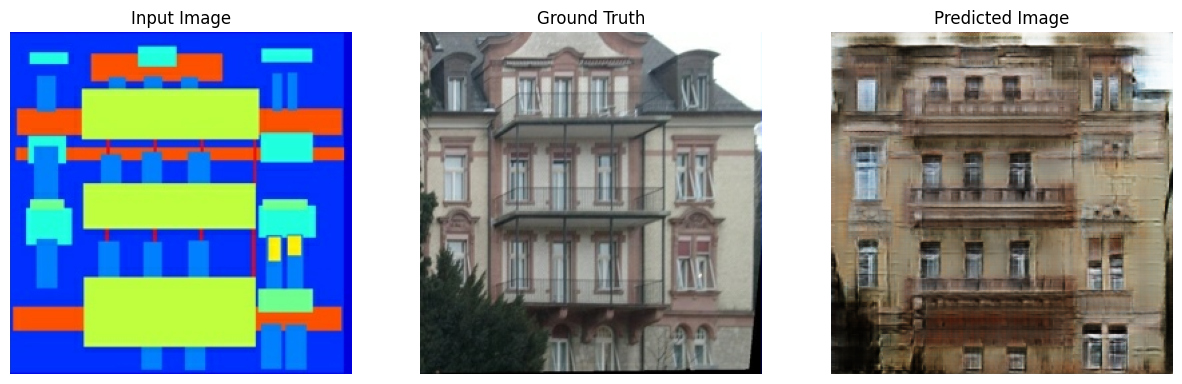

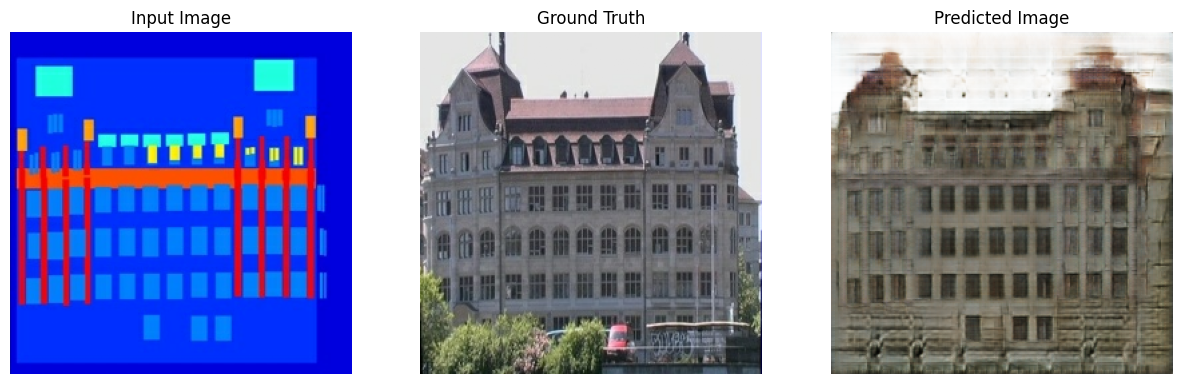

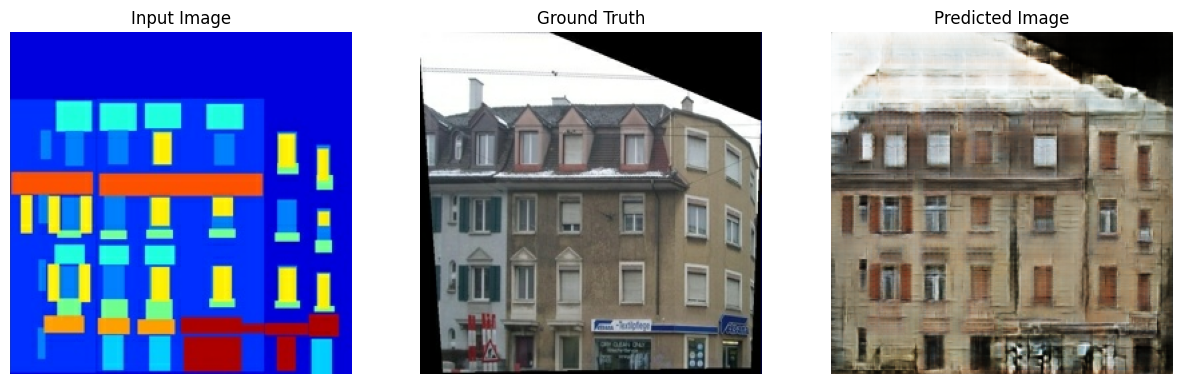

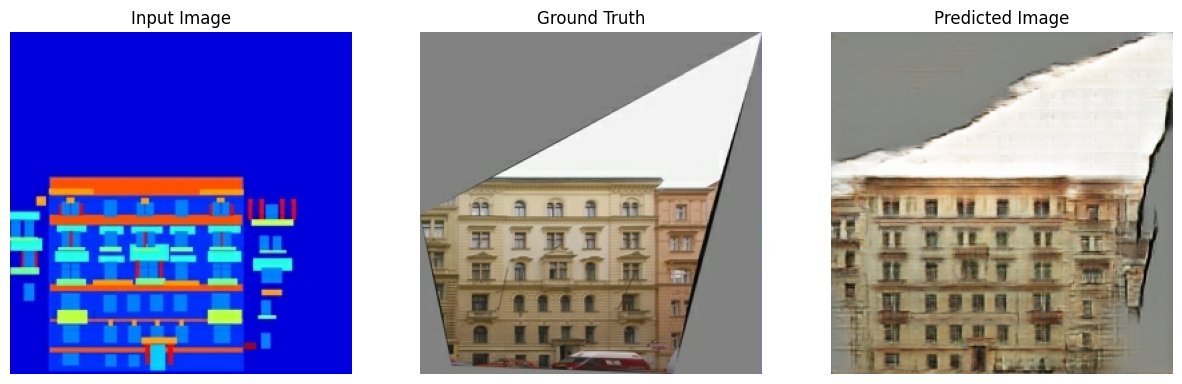

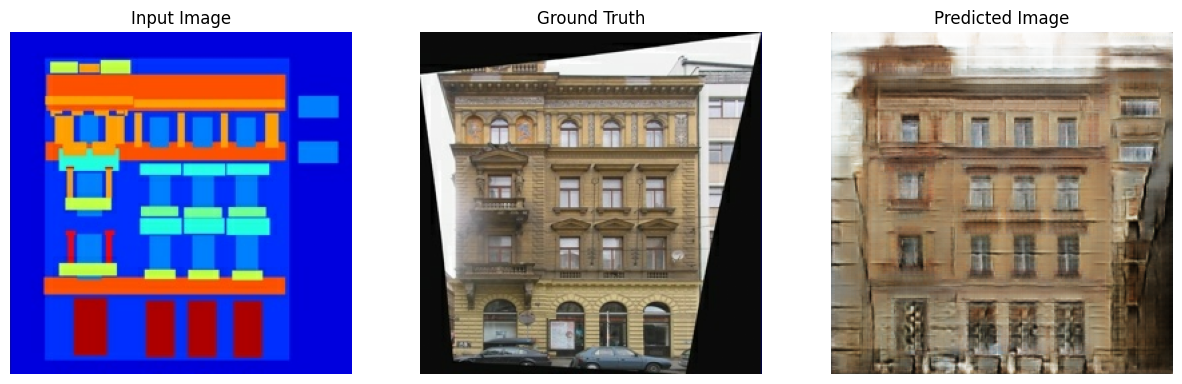

In [45]:
# Run the trained model on a few examples from the test set
for inp, tar in test_dataset.take(5):
  generate_images(generator, inp, tar)

## Experiment 1 : Evaluate the model’s performance with LPIPS (Learned Perceptual Image Patch Similarity)

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


/mnt/e_disk/ch24s016/ee6180_assignment1/pix2pix/virtualenv/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/mnt/e_disk/ch24s016/ee6180_assignment1/pix2pix/virtualenv/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: /mnt/e_disk/ch24s016/ee6180_assignment1/pix2pix/virtualenv/lib/python3.10/site-packages/lpips/weights/v0.1/alex.pth
Generator weights restored from checkpoint.


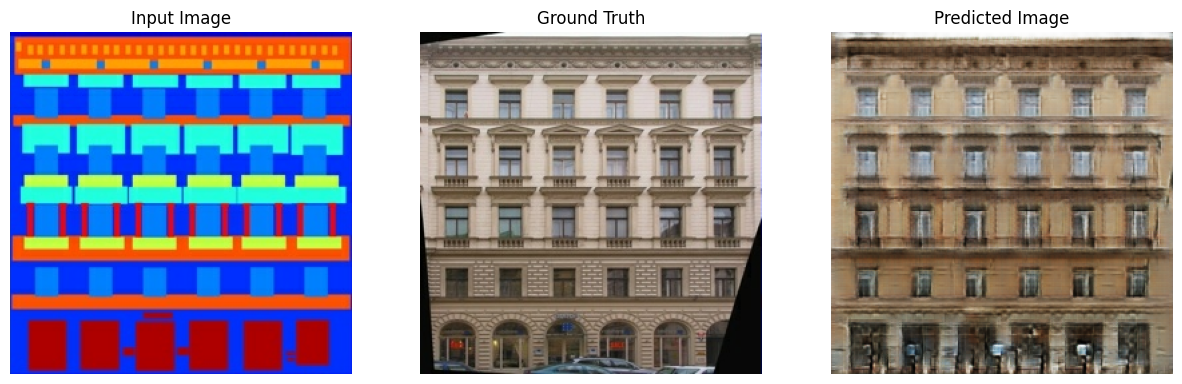

LPIPS (Learned Perceptual Image Patch Similarity) Score: 1.0174


In [107]:
import torch
import lpips
from PIL import Image
from torchvision import transforms
import tensorflow as tf
import numpy as np
from pytorch_fid import fid_score

# Initialize LPIPS model with alex we can also vgg
loss_fn = lpips.LPIPS(net='alex')  

generator = Generator()
checkpoint_dir = './training_checkpoints'
checkpoint = tf.train.Checkpoint(generator=generator)
checkpoint.restore(tf.train.latest_checkpoint(checkpoint_dir)).expect_partial()

print("Generator weights restored from checkpoint.")


def generate_output(image_path):
    input_image, real_image = load_image_test(image_path)      
    input_image = tf.expand_dims(input_image, axis=0)
    real_image = tf.expand_dims(real_image, axis=0)
    predicted_image = generate_images(generator, input_image, real_image)
    return predicted_image[0], real_image[0] 

def tf_to_lpips_tensor(tf_tensor):
    np_img = tf_tensor.numpy()

    np_img = (np.clip(np_img, 0, 1) * 255).astype(np.uint8)

    if np_img.ndim == 2:
        np_img = np.stack([np_img]*3, axis=-1)
    elif np_img.ndim == 3 and np_img.shape[-1] == 1:
        np_img = np.repeat(np_img, 3, axis=-1)
    elif np_img.ndim == 3 and np_img.shape[-1] == 3:
        pass 
    else:
        raise ValueError(f"Unexpected image shape: {np_img.shape}")

    
    pil_img = Image.fromarray(np_img)

    # Define transform
    transform = transforms.Compose([
        transforms.Resize((256, 256)),
        transforms.ToTensor(), 
        transforms.Normalize([0.5]*3, [0.5]*3), 
    ])

    torch_tensor = transform(pil_img).unsqueeze(0) 
    return torch_tensor


test_image_path = "/mnt/e_disk/ch24s016/ee6180_assignment1/pix2pix/datasets/facades/test/10.jpg"
predicted_image, real_image = generate_output(test_image_path)

fake = tf_to_lpips_tensor(predicted_image)
real = tf_to_lpips_tensor(real_image)


lpips_distance = loss_fn(real, fake)
print(f"LPIPS (Learned Perceptual Image Patch Similarity) Score: {lpips_distance.item():.4f}")


## Experiment 2 : Evaluate the model’s robustness to noisy inputs by adding salt and pepper noises to image and check is there more loss diffrence.

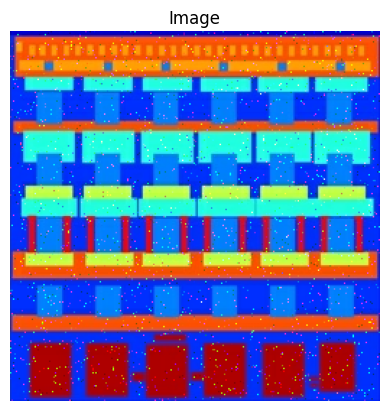

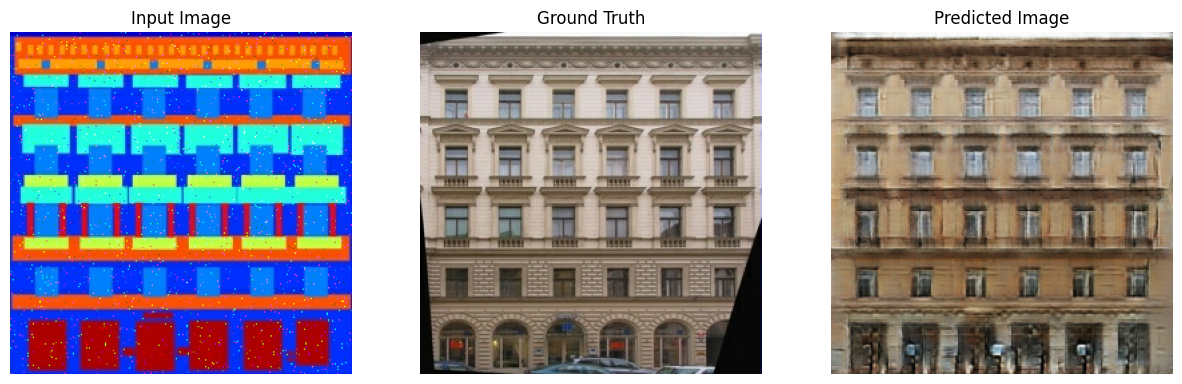

LPIPS (Learned Perceptual Image Patch Similarity) Score: 1.0270


In [106]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt



def display_image(image, title="Image"):
    # If image is in [-1, 1] range (typical for Pix2Pix), de-normalize it
    if tf.reduce_min(image) < 0:
        image = (image + 1) / 2  # Convert from [-1,1] to [0,1]

    plt.imshow(image.numpy())
    plt.axis("off")
    plt.title(title)
    plt.show()
      

def add_salt_and_pepper_noise(image, amount=0.05, salt_vs_pepper=0.5):
    image = tf.identity(image)  # make a copy
    total_pixels = tf.size(image) // 3  # only count per-channel pixels
    num_salt = tf.cast(amount * tf.cast(total_pixels, tf.float32) * salt_vs_pepper, tf.int32)
    num_pepper = tf.cast(amount * tf.cast(total_pixels, tf.float32) * (1.0 - salt_vs_pepper), tf.int32)

    # Add Salt (white pixels)
    indices_salt = tf.random.uniform([num_salt, 2], 0, image.shape[0], dtype=tf.int32)
    indices_salt = tf.concat([indices_salt, tf.random.uniform([num_salt, 1], 0, 3, dtype=tf.int32)], axis=1)
    updates_salt = tf.ones([num_salt], dtype=tf.float32)

    # Add Pepper (black pixels)
    indices_pepper = tf.random.uniform([num_pepper, 2], 0, image.shape[0], dtype=tf.int32)
    indices_pepper = tf.concat([indices_pepper, tf.random.uniform([num_pepper, 1], 0, 3, dtype=tf.int32)], axis=1)
    updates_pepper = tf.zeros([num_pepper], dtype=tf.float32)

    # Scatter updates
    sp_image = tf.tensor_scatter_nd_update(image, indices_salt, updates_salt)
    sp_image = tf.tensor_scatter_nd_update(sp_image, indices_pepper, updates_pepper)

    return sp_image

def add_speckle_noise(image, std=0.1):
    noise = tf.random.normal(shape=tf.shape(image), mean=0.0, stddev=std)
    noisy = image + image * noise
    return tf.clip_by_value(noisy, 0.0, 1.0)

def drop_random_channel(image):
    channel = tf.random.uniform([], 0, 3, dtype=tf.int32)
    mask = tf.one_hot(channel, 3, on_value=0.0, off_value=1.0)
    return image * mask


def generate_output(input_image_tensor,real_image): 

    
    # display_image(tf.squeeze(noisy_image, axis=0))
    noisy_image = add_salt_and_pepper_noise(input_image_tensor)
    display_image(noisy_image)
    noisy_image = tf.expand_dims(noisy_image, axis=0)
   
    input_image_tensor = tf.expand_dims(input_image_tensor, axis=0)
    real_image = tf.expand_dims(real_image, axis=0)
    predicted_image = generate_images(generator, noisy_image, real_image)
    return predicted_image[0], real_image[0]
    


test_image_path = "/mnt/e_disk/ch24s016/ee6180_assignment1/pix2pix/datasets/facades/test/10.jpg" 

input_image_tensor,real_image_tensor = load_image_test(test_image_path)

predicted_image, real_image = generate_output(input_image_tensor,real_image_tensor)


fake = tf_to_lpips_tensor(predicted_image)
real = tf_to_lpips_tensor(real_image)


lpips_distance = loss_fn(real, fake)
print(f"LPIPS (Learned Perceptual Image Patch Similarity) Score: {lpips_distance.item():.4f}")


## Experiment 3 : Evaluate the model’s perfomance on Cross domain datasets I have taken my pretrained model trained on facades and I am going to test with cityscapes where in cityscapes we have different semantic images for buildings compared to facades semantic images so lets see 

##### First I restoring the model which was already trained by me where I trained on facades dataset for 40K steps due to GPU and time constraints. Now I am going to see whether it can predict images for cityscape which is some how similar to facades may be atleast lets see whether building images is being detected or not 

Generator weights restored from checkpoint.


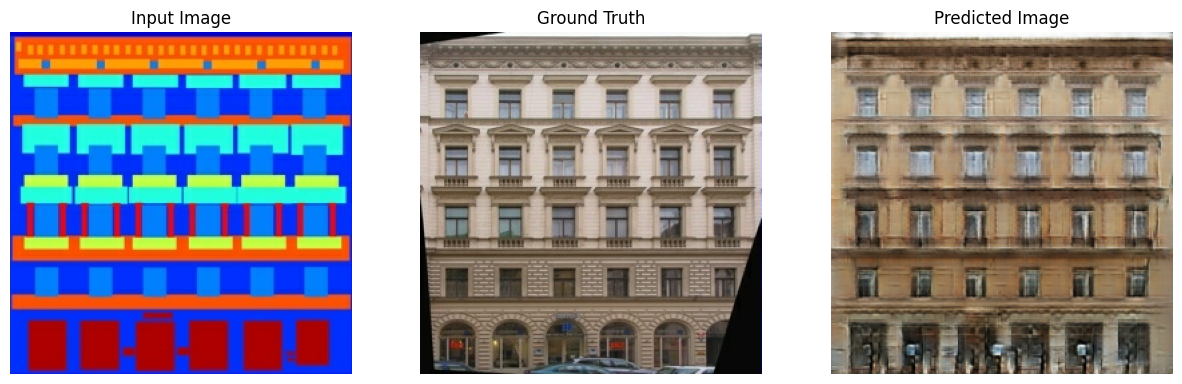

In [108]:
import tensorflow as tf
import os
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

generator = Generator()

checkpoint_dir = './training_checkpoints'
checkpoint = tf.train.Checkpoint(generator=generator)
checkpoint.restore(tf.train.latest_checkpoint(checkpoint_dir)).expect_partial()

print("Generator weights restored from checkpoint.")

def generate_output(image_path):
    input_image, real_image = load_image_test(image_path)      
    input_image = tf.expand_dims(input_image, axis=0)
    real_image = tf.expand_dims(real_image, axis=0)
    generate_images(generator, input_image, real_image)

# 5. Example: Run on one or multiple test images
test_image_path = "/mnt/e_disk/ch24s016/ee6180_assignment1/pix2pix/datasets/facades/test/10.jpg"             
generate_output(test_image_path)


Generator weights restored from checkpoint.


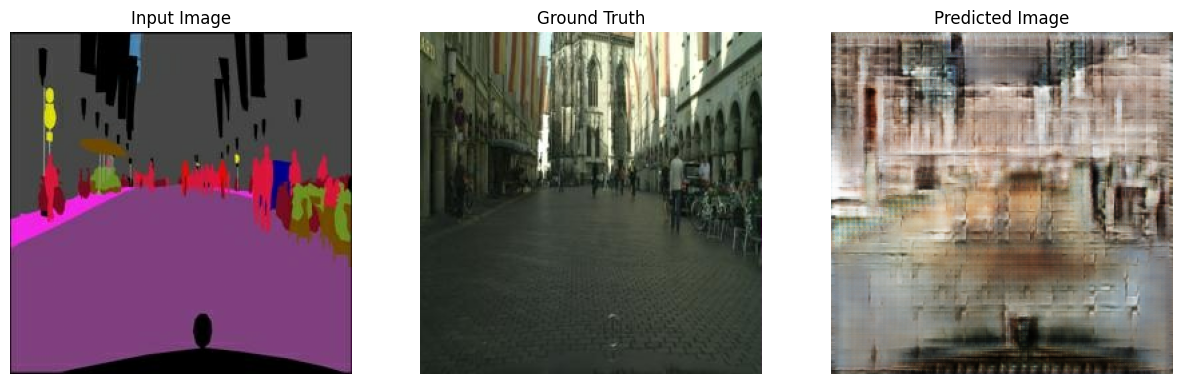

In [110]:
import tensorflow as tf
import os
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

generator = Generator()

checkpoint_dir = './training_checkpoints'
checkpoint = tf.train.Checkpoint(generator=generator)
checkpoint.restore(tf.train.latest_checkpoint(checkpoint_dir)).expect_partial()

print("Generator weights restored from checkpoint.")

def generate_output(image_path, output_path):
    input_image, real_image = load_image_test(image_path)      
    input_image = tf.expand_dims(input_image, axis=0)
    real_image = tf.expand_dims(real_image, axis=0)
    generate_images(generator, input_image, real_image)

# 5. Example: Run on one or multiple test images
test_image_path = "/mnt/e_disk/ch24s016/ee6180_assignment1/pix2pix/datasets/cityscapes/test/472.jpg"      
output_image_path = "/mnt/e_disk/ch24s016/ee6180_assignment1/pix2pix/results/output1.jpg"          
generate_output(test_image_path, output_image_path)
